# **V-JEPA 2: Self-Supervised Video Models Enable Understanding, Prediction and Planning (Meta FAIR).**

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
torch.manual_seed(42)
random.seed(42)

# **Action-Conditioned Frame Sequence Generator**

To make this run instantly without needing to upload heavy (.mp4) robotic or game trajectories, this cell dynamically renders a canvas with an object moving across a 2D grid based on continuous directional velocity steps. It splits data into the Current Observation, the Executed Action, and the True Next Target Observation.

In [8]:
class ActionVideoDataset(torch.utils.data.Dataset):
  def __init__ (self, canvas_size=32, steps=5):
    self.canvas_size = canvas_size
    self.steps = steps

    def __len__(self):
      return 200 ##STD Epoch iteration

    def __getitem_(self, idx):
      frames = []
      actions = []

      x, y= random.ranadint(5,12), random.randint(5,12)

      for _ in range(self.steps):
        img = Image.new('RGB', (self.canvas_size, self.canvas_size), color='black')
        draw = ImageDraw.Draw(img)
        draw.rectangle([x, y, x+6, y+6], fill='cyan') ##Simulated Target Element

        tensor= transforms.ToTensor()(img)
        frames.append(tensor)

        ##Generating a continous action vector: [dx, dy] mapped within [-1,1] bounds
        dx = random.choice([-2,-1,0,1,2])
        dy = random.choice([-2,-1,0,1,2])
        actions.append(torch.tensor([dx / 2.0, dy / 2.0], dtype=torch.float32))

        ##Transition position states
        x = max(0, min(self.canvas_size - 7, x+dx))
        y = max(0, min(self.canvas_size - 7, y+dy))

        # Structure the sequences
      obs_sequence = torch.stack(frames[:-1], dim=1)     # [C, T-1, H, W] -> Current inputs
      next_sequence = torch.stack(frames[1:], dim=1)      # [C, T-1, H, W] -> Future target frames
      action_sequence = torch.stack(actions[:-1], dim=0) # [T-1, 2] -> Directing forces

      return obs_sequence, action_sequence, next_sequence


# **Observation Encoders (Trainable Context and Frozen Target)**
Builds a convolutional visual backbone that flattens spatial video representations directly into unified abstract state configurations, discarding pixel-space decoding loops.


In [9]:
class ObservationEncoder(nn.Module):
    """Encodes standard 2D observation frames into abstract feature vectors."""
    def __init__(self, in_channels=3, embed_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=4, stride=2, padding=1), # [16, 16, 16]
            nn.ReLU(),
            nn.Conv2d(16, embed_dim, kernel_size=4, stride=2, padding=1),   # [64, 8, 8]
            nn.ReLU(),
            nn.Flatten(1)
        )
        self.fc = nn.Linear(embed_dim * 8 * 8, embed_dim)

    def forward(self, x):
        return self.fc(self.conv(x))

# **Action-Conditioned Transition Predictor**
The core evolution of V-JEPA 2. Instead of using generic mask tokens, this module embeds the vector of an action command ($a_t$), couples it with the current latent embedding ($z_t$), and predicts the updated future representation ($z_{t+1}$) directly inside the hidden state manifold.


# **Unified V-JEPA 2 System Shell**
This cell wraps the components together, establishing the dual Siamese tracking track complete with a strict stop-gradient on the Target Encoder and the Exponential Moving Average (EMA) weight updater.

In [25]:
class VideoJEPA2(nn.Module):
    def __init__(self, embed_dim=64, action_dim=2):
        super().__init__()
        self.context_encoder = ObservationEncoder(embed_dim=embed_dim)
        self.target_encoder = ObservationEncoder(embed_dim=embed_dim)
        self.predictor = ActionConditionedPredictor(embed_dim=embed_dim, action_dim=action_dim)

        # Target Encoder weights frozen from normal backprop updates
        for param in self.target_encoder.parameters():
            param.requires_grad = False

    def update_target_ema(self, momentum=0.99):
        """EMA Weight Update: Prevents latent representation collapse."""
        for c_param, t_param in zip(self.context_encoder.parameters(), self.target_encoder.parameters()):
            t_param.data = t_param.data * momentum + c_param.data * (1.0 - momentum)

    def forward(self, obs, action, target_obs):
        B, C, T, H, W = obs.size()
        pred_latents = []
        true_latents = []

        # Step sequentially through time sequence fragments
        for t in range(T):
            curr_frame = obs[:, :, t, :, :]
            next_frame = target_obs[:, :, t, :, :]
            curr_action = action[:, t, :]

            # Map current context states
            z_t = self.context_encoder(curr_frame)

            # Predict subsequent states via localized actions
            z_next_pred = self.predictor(z_t, curr_action)

            with torch.no_grad():
                # Extract ground truth target features with strict stop-gradient isolation
                z_next_true = self.target_encoder(next_frame)

            pred_latents.append(z_next_pred)
            true_latents.append(z_next_true)

        return torch.stack(pred_latents, dim=1), torch.stack(true_latents, dim=1)

# **Force Freshing Dataset due to TypeError**

In [21]:
# Force-refresh the dataset instance with explicit length definition
class FixedActionVideoDataset(ActionVideoDataset):
    def __len__(self):
        return 128  # Explicitly tell the DataLoader how many sequences to run per epoch

# Re-instantiate the pipeline components
dataset = ColabActionVideoDataset()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Dataset successfully registered! Total sequence samples: {len(dataset)}")
print(f"Total batches per epoch: {len(dataloader)}")

Dataset successfully registered! Total sequence samples: 128
Total batches per epoch: 8


In [23]:
# Create a fresh, uniquely named class to force Colab to update its memory cache
class ColabActionVideoDataset(torch.utils.data.Dataset):
    def __init__(self, canvas_size=32, steps=5):
        self.canvas_size = canvas_size
        self.steps = steps

    def __len__(self):
        return 128  # Explicitly defined for the DataLoader

    def __getitem__(self, idx):
        frames = []
        actions = []
        x, y = random.randint(5, 12), random.randint(5, 12)
        move_choices = [-2, -1, 0, 1, 2]

        for _ in range(self.steps):
            img = Image.new('RGB', (self.canvas_size, self.canvas_size), color='black')
            draw = ImageDraw.Draw(img)
            draw.rectangle([x, y, x+6, y+6], fill='cyan')

            tensor = transforms.ToTensor()(img)
            frames.append(tensor)

            dx = random.choice(move_choices)
            dy = random.choice(move_choices)
            actions.append(torch.tensor([dx / 2.0, dy / 2.0], dtype=torch.float32))

            x = max(0, min(self.canvas_size - 7, x + dx))
            y = max(0, min(self.canvas_size - 7, y + dy))

        obs_sequence = torch.stack(frames[:-1], dim=1)
        next_sequence = torch.stack(frames[1:], dim=1)
        action_sequence = torch.stack(actions[:-1], dim=0)

        return obs_sequence, action_sequence, next_sequence

# Re-instantiate the pipeline components using the fresh class
dataset = ColabActionVideoDataset()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

print(f"✅ Dataset successfully updated! Total samples: {len(dataset)}")
print(f"✅ Total batches per epoch: {len(dataloader)}")

✅ Dataset successfully updated! Total samples: 128
✅ Total batches per epoch: 8


# **Optimization Loop and World Model  Visualization**
Runs the world model dynamics training across 20 epochs using an MSE criterion inside the feature space, then graphs the latent convergence curve.

🎬 Booting Action-Conditioned V-JEPA 2 World Model on: cuda

--- Starting Action-Conditioned Trajectory Pre-Training ---
Epoch 01/20 | World Model Transition MSE: 0.055250
Epoch 02/20 | World Model Transition MSE: 0.007919
Epoch 03/20 | World Model Transition MSE: 0.003357
Epoch 04/20 | World Model Transition MSE: 0.001610
Epoch 05/20 | World Model Transition MSE: 0.000791
Epoch 06/20 | World Model Transition MSE: 0.000520
Epoch 07/20 | World Model Transition MSE: 0.000322
Epoch 08/20 | World Model Transition MSE: 0.000228
Epoch 09/20 | World Model Transition MSE: 0.000180
Epoch 10/20 | World Model Transition MSE: 0.000151
Epoch 11/20 | World Model Transition MSE: 0.000129
Epoch 12/20 | World Model Transition MSE: 0.000117
Epoch 13/20 | World Model Transition MSE: 0.000106
Epoch 14/20 | World Model Transition MSE: 0.000094
Epoch 15/20 | World Model Transition MSE: 0.000088
Epoch 16/20 | World Model Transition MSE: 0.000082
Epoch 17/20 | World Model Transition MSE: 0.000076
Epoch 18/20 |

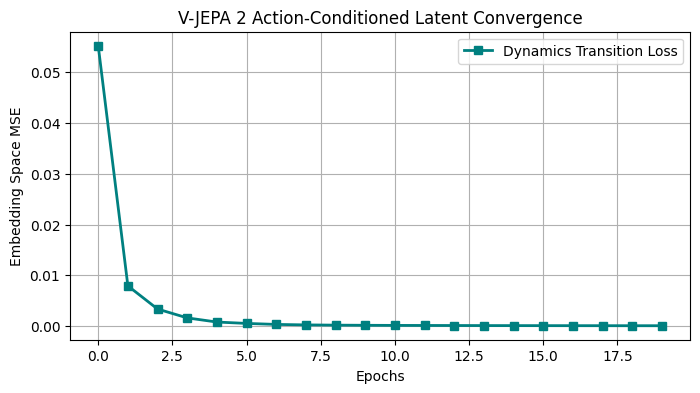

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🎬 Booting Action-Conditioned V-JEPA 2 World Model on: {device}")

# Instantiations
dataset = ColabActionVideoDataset()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)--

model = VideoJEPA2().to(device)
optimizer = optim.AdamW(list(model.context_encoder.parameters()) + list(model.predictor.parameters()), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

loss_history = []

model.train()
print("\n--- Starting Action-Conditioned Trajectory Pre-Training ---")
for epoch in range(20):
    epoch_loss = 0.0
    for obs, actions, targets in dataloader:
        obs, actions, targets = obs.to(device), actions.to(device), targets.to(device)

        optimizer.zero_grad()
        predicted_vectors, true_vectors = model(obs, actions, targets)

        # Loss computed entirely in latent space (No pixel generation!)
        loss = criterion(predicted_vectors, true_vectors)
        loss.backward()
        optimizer.step()

        # Update the target tracking pathway
        model.update_target_ema(momentum=0.99)
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/20 | World Model Transition MSE: {avg_loss:.6f}")

# Plotting Results
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='teal', marker='s', linewidth=2, label='Dynamics Transition Loss')
plt.title('V-JEPA 2 Action-Conditioned Latent Convergence')
plt.xlabel('Epochs')
plt.ylabel('Embedding Space MSE')
plt.grid(True)
plt.legend()
plt.show()